In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import glob
import os
import re
import matplotlib 
import matplotlib as mpl
from pathlib import Path

In [16]:
driver = "vGAT"
responder = "eOPN3_ATR"

laptop = "C:\\Users\\lnico"
workcomp = "C:\\Users\\User"
homecomp = "D:"
base_path = "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data compilation\\Trumelan\\2. Processed\\"  
specifiedpath = workcomp + base_path

bin_size = 0.5  # seconds for heatmap resampling
framerate = 10  # Hz
illum_start = 60  # illumination start (seconds)
maxtime = 3600
specifictime = 600  # for shorter time plots (seconds)

#'ActivityLevel' or 'Speed'
metric_to_plot = 'ActivityLevel'

## Stacked by Illumination Duration

In [9]:
duration_files = {
    '0s': specifiedpath + driver + " x " + responder + "_0s",
    '5s': specifiedpath + driver + " x " + responder + "_5s",
    '30s': specifiedpath + driver + " x " + responder + "_30s",
    '60s': specifiedpath + driver + " x " + responder + "_60s",
}


duration_plot_title = driver + " > " + responder + " - Illumination Duration"

In [10]:
duration_data = {}

for label, filepath in duration_files.items():
    df = pd.read_csv(filepath + "_max" + str(maxtime) + "s.csv").set_index('Time (s)')
    df = df.iloc[0:(specifictime*2), :]  # trim to specifictime
    duration_data[label] = df.filter(regex="^" + metric_to_plot).T.reset_index(drop=True)

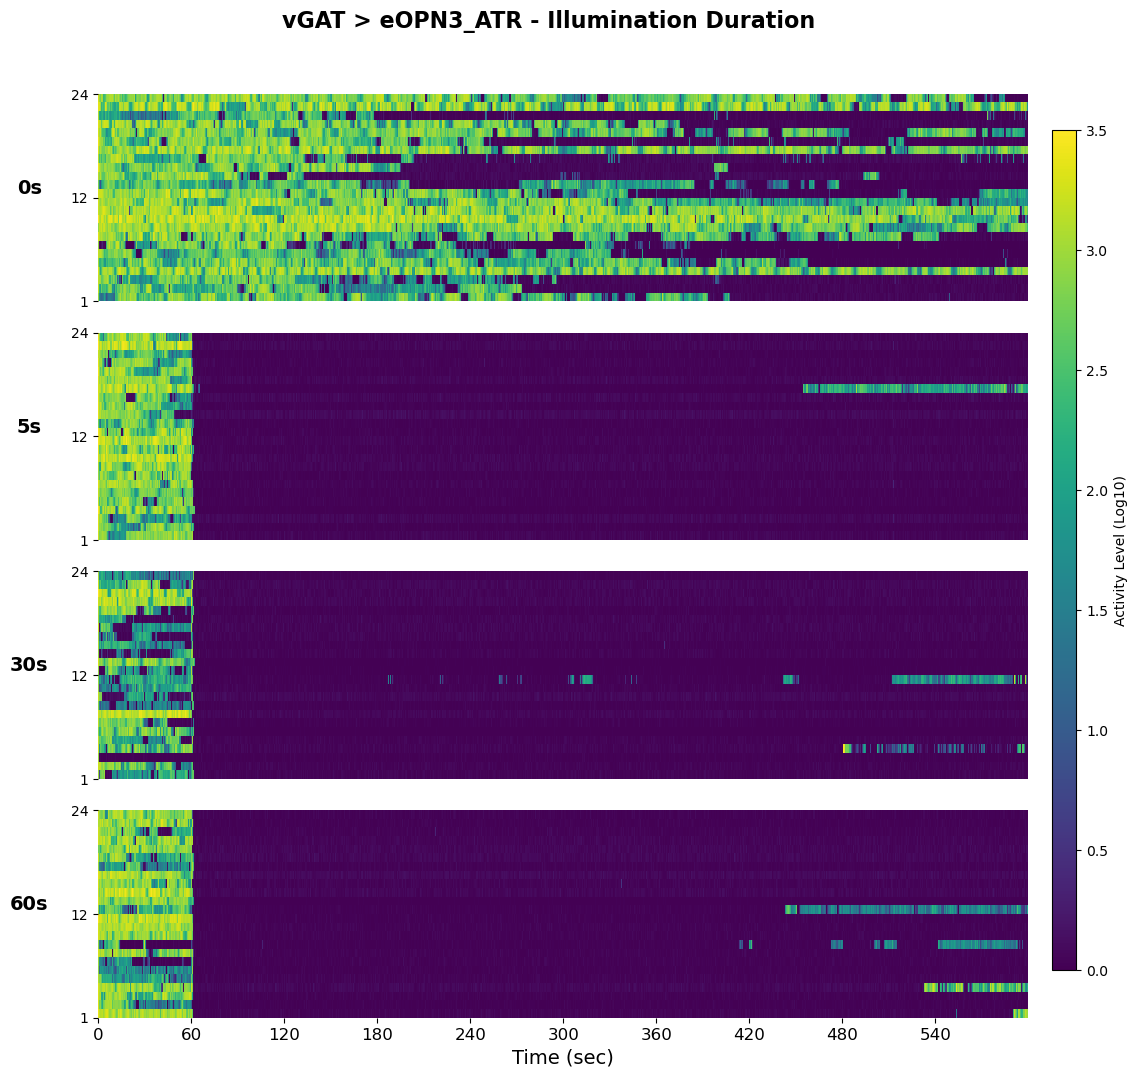

In [11]:
num_conditions = len(duration_data)
fig, axes = plt.subplots(num_conditions, 1, figsize=(12, 3*num_conditions), sharex=True)
plt.subplots_adjust(hspace=0.15)

if metric_to_plot == "ActivityLevel":
    scalebar_label = "Activity Level (Log10)"
elif metric_to_plot == "Speed":
    scalebar_label = "Speed (mm/s)"

for idx, (label, data) in enumerate(duration_data.items()):
    ax = axes[idx]
    num_flies = data.shape[0]
    
    hm = sns.heatmap(data, cmap="viridis", cbar=False, xticklabels=False, yticklabels=False, 
                     vmin=0, vmax=3.5, ax=ax)
    quadmesh = ax.collections[0]
    quadmesh.set_rasterized(True)
    quadmesh.set_edgecolor('face')
    quadmesh.set_linewidth(0)
    
    ax.set_ylabel(label, rotation=0, labelpad=30, fontsize=14, weight='bold')
    ax.set_yticks([0, num_flies//2, num_flies])
    ticklabels = [num_flies, (num_flies+1)//2, 1]
    ax.set_yticklabels(ticklabels, fontsize=10)
    
    if idx < num_conditions - 1:
        ax.tick_params(axis='x', bottom=False)
        ax.set_xlabel('')
    ax.patch.set_facecolor('white')


last_data = list(duration_data.values())[-1]
tick_times = list(range(0, int(specifictime), int(specifictime/10)))
tick_positions = [list(last_data.columns).index(float(t)) for t in tick_times if float(t) in last_data.columns]
axes[-1].set_xticks(tick_positions)
axes[-1].set_xticklabels(tick_times, rotation=0, fontsize=12)
axes[-1].set_xlabel("Time (sec)", fontsize=14)


cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
sm = plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(vmin=0, vmax=3.5))
fig.colorbar(sm, cax=cbar_ax, label=scalebar_label)

fig.suptitle(duration_plot_title, weight="bold", fontsize=16, y=0.95)

mpl.rcParams['svg.fonttype'] = 'none'
fig.patch.set_facecolor('white')

# plt.savefig(homecomp + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data compilation\\Trumelan\\Trumelan images\\"
#             + "Stacked_duration_" + driver + "_" + responder + ".svg",
#             dpi=300, bbox_inches='tight', format='svg', facecolor='white', transparent=False)

## Stacked by Light Intensity

In [12]:
intensity_files = {
    'No Light': specifiedpath + driver + " x " + responder + "_0s",
    'Quarter': specifiedpath + driver + " x " + responder + "_quarter_5s",
    'Half': specifiedpath + driver + " x " + responder + "_half_5s",
    'Full': specifiedpath + driver + " x " + responder + "_5s",
}

intensity_plot_title = driver + " > " + responder + " - Light Intensity"

In [13]:
intensity_data = {}

for label, filepath in intensity_files.items():
    df = pd.read_csv(filepath + "_max" + str(maxtime) + "s.csv").set_index('Time (s)')
    df = df.iloc[0:(specifictime*2), :]  # trim to specifictime
    intensity_data[label] = df.filter(regex="^" + metric_to_plot).T.reset_index(drop=True)
    print(f"{label}: {intensity_data[label].shape[0]} flies")

No Light: 24 flies
Quarter: 43 flies
Half: 24 flies
Full: 24 flies


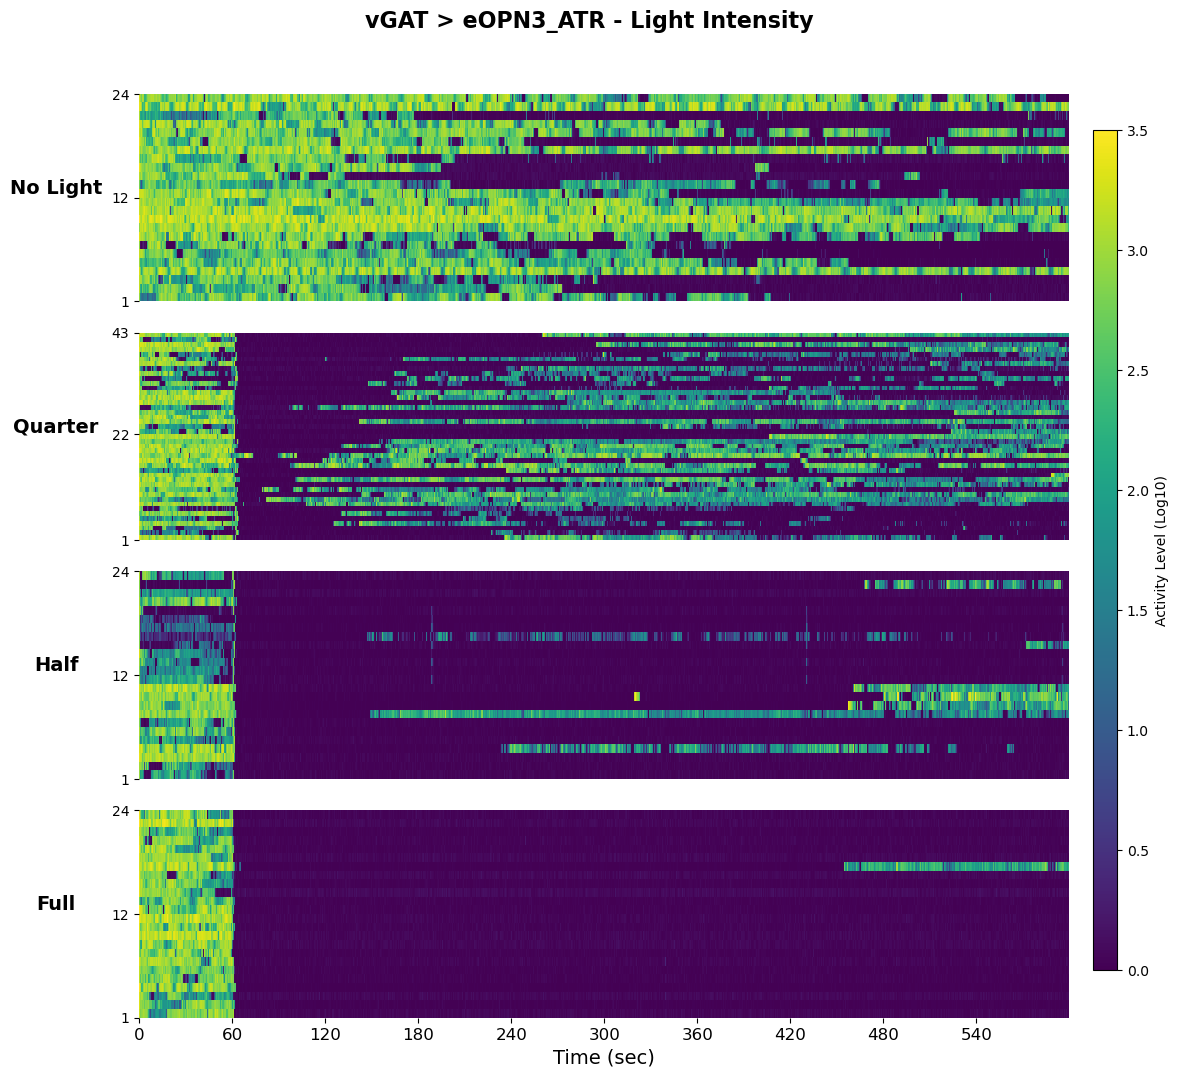

In [14]:
num_conditions = len(intensity_data)
fig, axes = plt.subplots(num_conditions, 1, figsize=(12, 3*num_conditions), sharex=True)
plt.subplots_adjust(hspace=0.15)

if metric_to_plot == "ActivityLevel":
    scalebar_label = "Activity Level (Log10)"
elif metric_to_plot == "Speed":
    scalebar_label = "Speed (mm/s)"

for idx, (label, data) in enumerate(intensity_data.items()):
    ax = axes[idx]
    num_flies = data.shape[0]
    
    hm = sns.heatmap(data, cmap="viridis", cbar=False, xticklabels=False, yticklabels=False, 
                     vmin=0, vmax=3.5, ax=ax)
    quadmesh = ax.collections[0]
    quadmesh.set_rasterized(True)
    quadmesh.set_edgecolor('face')
    quadmesh.set_linewidth(0)
    
    ax.set_ylabel(label, rotation=0, labelpad=40, fontsize=14, weight='bold')
    ax.set_yticks([0, num_flies//2, num_flies])
    ticklabels = [num_flies, (num_flies+1)//2, 1]
    ax.set_yticklabels(ticklabels, fontsize=10)
    
    if idx < num_conditions - 1:
        ax.tick_params(axis='x', bottom=False)
        ax.set_xlabel('')
    ax.patch.set_facecolor('white')

last_data = list(intensity_data.values())[-1]
tick_times = list(range(0, int(specifictime), int(specifictime/10)))
tick_positions = [list(last_data.columns).index(float(t)) for t in tick_times if float(t) in last_data.columns]
axes[-1].set_xticks(tick_positions)
axes[-1].set_xticklabels(tick_times, rotation=0, fontsize=12)
axes[-1].set_xlabel("Time (sec)", fontsize=14)

cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
sm = plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(vmin=0, vmax=3.5))
fig.colorbar(sm, cax=cbar_ax, label=scalebar_label)

fig.suptitle(intensity_plot_title, weight="bold", fontsize=16, y=0.95)

mpl.rcParams['svg.fonttype'] = 'none'
fig.patch.set_facecolor('white')

# plt.savefig(homecomp + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data compilation\\Trumelan\\Trumelan images\\"
#             + "Stacked_intensity_" + driver + "_" + responder + ".svg",
#             dpi=300, bbox_inches='tight', format='svg', facecolor='white', transparent=False)

## Line Graphs

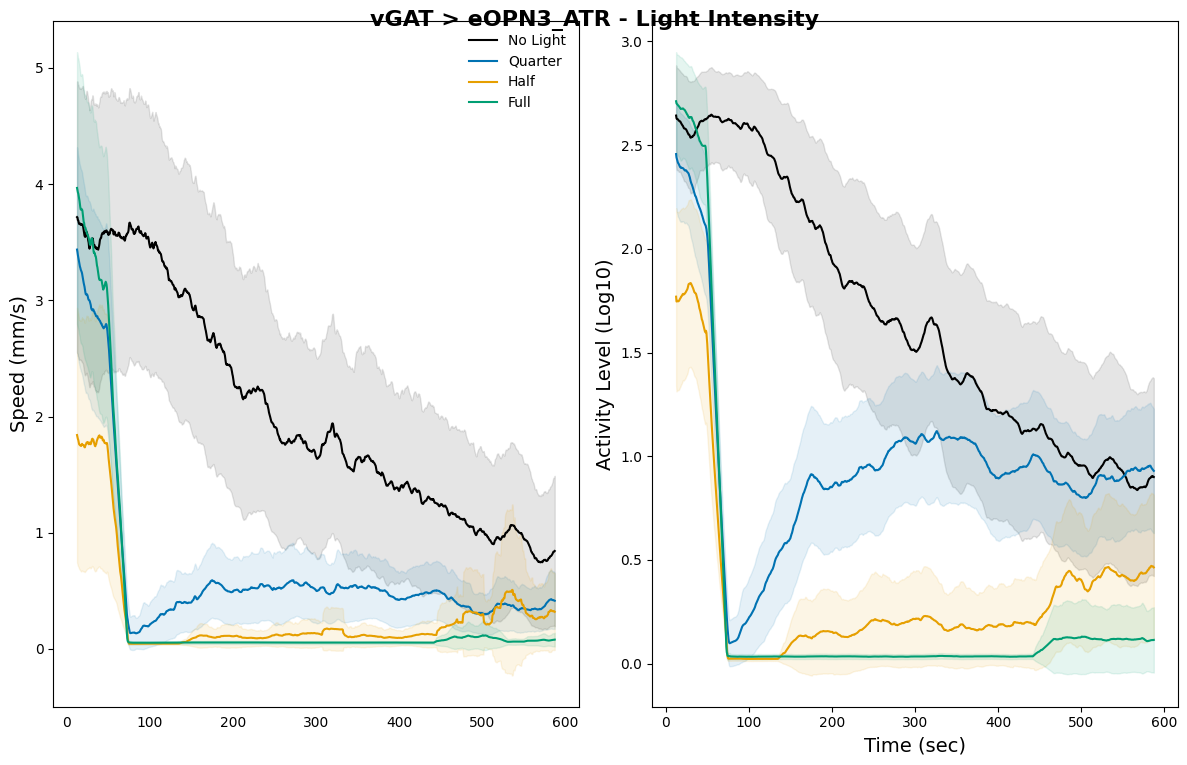

In [ ]:
line_colors = {
    'No Light': '#000000',
    'Quarter': '#0072B2',
    'Half': '#E69F00',
    'Full': '#009E73'
}

intensity_files_line = {
    'No Light': specifiedpath + driver + " x " + responder + "_0s",
    'Quarter': specifiedpath + driver + " x " + responder + "_quarter_5s",
    'Half': specifiedpath + driver + " x " + responder + "_half_5s",
    'Full': specifiedpath + driver + " x " + responder + "_5s",
}

rolling_window = 50
intensity_speed = {}
intensity_activity = {}

for label, filepath in intensity_files_line.items():
    df = pd.read_csv(filepath + "_max" + str(maxtime) + "s.csv").set_index('Time (s)')
    df = df.iloc[0:(specifictime*2), :]

    speed_df = df.filter(regex="^Speed").T.reset_index(drop=True)
    activity_df = df.filter(regex="^ActivityLevel").T.reset_index(drop=True)

    intensity_speed[label] = speed_df
    intensity_activity[label] = activity_df

fig, axes = plt.subplots(1, 2, figsize=(12, 8), sharex=True)
plt.subplots_adjust(hspace=0.1)


ax_speed = axes[0]
for label, data in intensity_speed.items():
    time = data.columns.values
    mean_vals = data.mean(axis=0).rolling(window=rolling_window, center=True, min_periods=1).mean()
    sem_vals = data.sem(axis=0).rolling(window=rolling_window, center=True, min_periods=1).mean()
    ci = 1.96 * sem_vals

    ax_speed.plot(time, mean_vals, color=line_colors[label], label=label, linewidth=1.5)
    ax_speed.fill_between(time, mean_vals - ci, mean_vals + ci, color=line_colors[label], alpha=0.1)

ax_speed.set_ylabel("Speed (mm/s)", fontsize=14)
ax_speed.legend(loc='upper right', frameon=False)
ax_speed.tick_params(axis='x', bottom=False)


ax_activity = axes[1]
for label, data in intensity_activity.items():
    time = data.columns.values
    mean_vals = data.mean(axis=0).rolling(window=rolling_window, center=True, min_periods=1).mean()
    sem_vals = data.sem(axis=0).rolling(window=rolling_window, center=True, min_periods=1).mean()
    ci = 1.96 * sem_vals

    ax_activity.plot(time, mean_vals, color=line_colors[label], label=label, linewidth=1.5)
    ax_activity.fill_between(time, mean_vals - ci, mean_vals + ci, color=line_colors[label], alpha=0.1)

ax_activity.set_ylabel("Activity Level (Log10)", fontsize=14)
ax_activity.set_xlabel("Time (sec)", fontsize=14)

fig.suptitle(driver + " > " + responder + " - Light Intensity", weight="bold", fontsize=16, y=0.95)
mpl.rcParams['svg.fonttype'] = 'none'
fig.patch.set_facecolor('white')
plt.tight_layout()

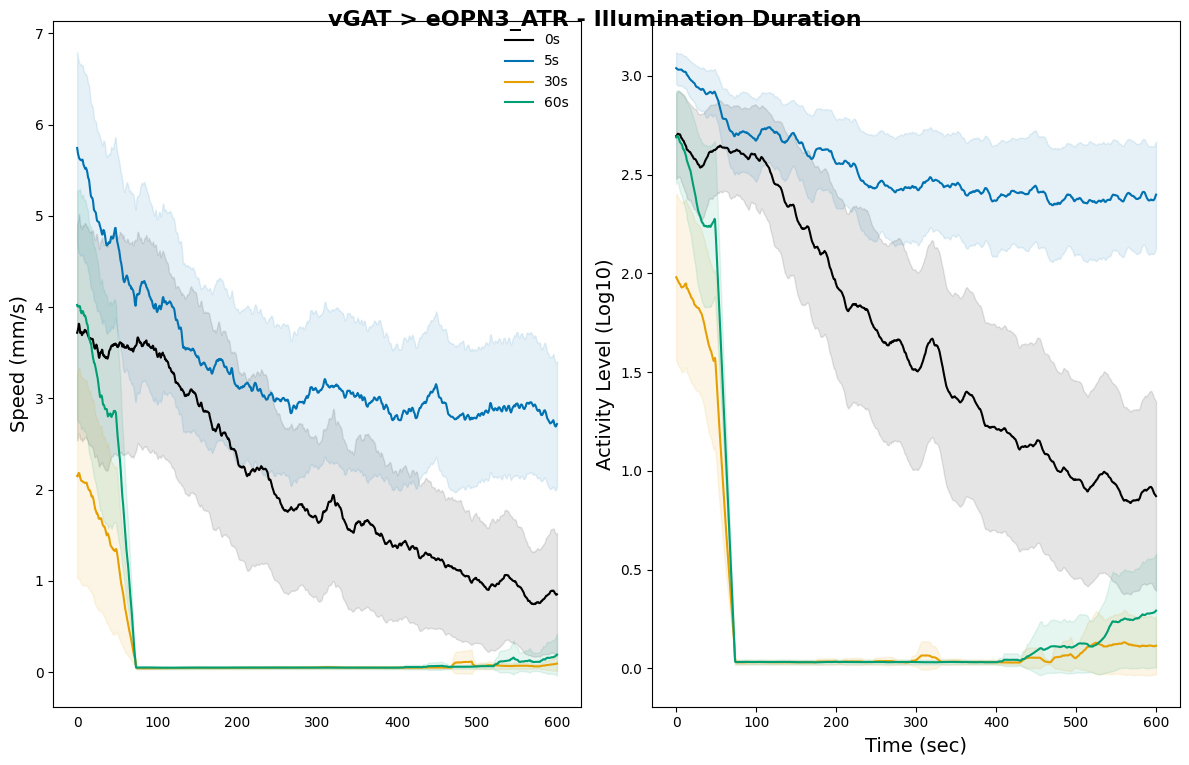

In [26]:
# Line Graph - Light Duration
# Colorblind-friendly palette: black for 0s, then blue, orange, green
line_colors_duration = {
    '0s': '#000000',
    '5s': '#0072B2',
    '30s': '#E69F00',
    '60s': '#009E73'
}

duration_files_line = {
    '0s': specifiedpath + driver + " x " + responder + "_0s",
    '5s': specifiedpath + "w1118 x elav_ATR" + "_5s",
    '30s': specifiedpath + driver + " x " + responder + "_30s",
    '60s': specifiedpath + driver + " x " + responder + "_60s",
}

rolling_window = 50  # rolling window size

# Load data for both metrics
duration_speed = {}
duration_activity = {}

for label, filepath in duration_files_line.items():
    df = pd.read_csv(filepath + "_max" + str(maxtime) + "s.csv").set_index('Time (s)')
    df = df.iloc[0:(specifictime*2), :]

    speed_df = df.filter(regex="^Speed").T.reset_index(drop=True)
    activity_df = df.filter(regex="^ActivityLevel").T.reset_index(drop=True)

    duration_speed[label] = speed_df
    duration_activity[label] = activity_df

# Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 8), sharex=True)
plt.subplots_adjust(hspace=0.1)

# Plot Speed (top)
ax_speed = axes[0]
for label, data in duration_speed.items():
    time = data.columns.values
    mean_vals = data.mean(axis=0).rolling(window=rolling_window, center=True, min_periods=1).mean()
    sem_vals = data.sem(axis=0).rolling(window=rolling_window, center=True, min_periods=1).mean()
    ci = 1.96 * sem_vals

    ax_speed.plot(time, mean_vals, color=line_colors_duration[label], label=label, linewidth=1.5)
    ax_speed.fill_between(time, mean_vals - ci, mean_vals + ci, color=line_colors_duration[label], alpha=0.1)

ax_speed.set_ylabel("Speed (mm/s)", fontsize=14)
ax_speed.legend(loc='upper right', frameon=False)
ax_speed.tick_params(axis='x', bottom=False)

# Plot Activity Level (bottom)
ax_activity = axes[1]
for label, data in duration_activity.items():
    time = data.columns.values
    mean_vals = data.mean(axis=0).rolling(window=rolling_window, center=True, min_periods=1).mean()
    sem_vals = data.sem(axis=0).rolling(window=rolling_window, center=True, min_periods=1).mean()
    ci = 1.96 * sem_vals

    ax_activity.plot(time, mean_vals, color=line_colors_duration[label], label=label, linewidth=1.5)
    ax_activity.fill_between(time, mean_vals - ci, mean_vals + ci, color=line_colors_duration[label], alpha=0.1)

ax_activity.set_ylabel("Activity Level (Log10)", fontsize=14)
ax_activity.set_xlabel("Time (sec)", fontsize=14)

fig.suptitle(driver + " > " + responder + " - Illumination Duration", weight="bold", fontsize=16, y=0.95)
mpl.rcParams['svg.fonttype'] = 'none'
fig.patch.set_facecolor('white')
plt.tight_layout()

## Dabest

In [ ]:
intensity_files_line = {
    'No Light': specifiedpath + driver + " x " + responder + "_0s",
    'Quarter': specifiedpath + driver + " x " + responder + "_quarter_5s",
    'Half': specifiedpath + driver + " x " + responder + "_half_5s",
    'Full': specifiedpath + driver + " x " + responder + "_5s",
}

rolling_window = 50
intensity_speed = {}
intensity_activity = {}

first_phase = slice(0,(60*2)-0.5)
light_on = slice((60*2),(60*2)+(5.0*2)-0.5)#frame before light off takes control because i.e the 65th second is when the light goes off
onemin_phase = slice((60*2)+(5.0*2),(60*2)*2+(5.0*2)-0.5)
fivemin_phase = slice((60*2)*2+(5.0*2),(60*2)*2+(5.0*2) + 600-0.5)


for label, filepath in intensity_files_line.items():
    df = pd.read_csv(filepath + "_max" + str(maxtime) + "s.csv").set_index('Time (s)')
    df = df.loc[fivemin_phase, :]

    speed_df = df.filter(regex="^Speed").T.reset_index(drop=True)
    activity_df = df.filter(regex="^ActivityLevel").T.reset_index(drop=True)

    intensity_speed[label] = speed_df
    intensity_activity[label] = activity_df


for label, data in intensity_speed.items():
    df[label] = mean_vals = data.mean(axis=1)

mean_vals
    

0     0.089996
1     0.089996
2     0.089996
3     0.089996
4     0.089996
5     0.089996
6     0.089996
7     0.089996
8     0.089996
9     0.089996
10    0.089996
11    0.089996
12    0.089996
13    0.089996
14    0.089996
15    0.089996
16    0.089996
17    0.089996
18    0.089996
19    0.089996
20    0.089996
21    0.089996
22    0.089996
23    0.089996
dtype: float64

In [41]:
label

'Full'